In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(len(filenames))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

4
4
4
4


In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import os

In [8]:
!ls -la /kaggle/input/datasets/fedesoriano/cifar100/

total 181944
drwxr-xr-x 2 nobody nogroup         0 Jun 18 20:47 .
drwxr-xr-x 3 root   root         4096 Jun 23 04:19 ..
-rw-r--r-- 1 nobody nogroup         0 Jun 18 20:47 file.txt
-rw-r--r-- 1 nobody nogroup      1473 Jun 18 20:47 meta
-rw-r--r-- 1 nobody nogroup  31049707 Jun 18 20:47 test
-rw-r--r-- 1 nobody nogroup 155249918 Jun 18 20:48 train


In [9]:
import pickle

with open("/kaggle/input/datasets/fedesoriano/cifar100/train", "rb") as f:
    train_dict = pickle.load(f, encoding="bytes")
with open("/kaggle/input/datasets/fedesoriano/cifar100/test", "rb") as f:
    test_dict = pickle.load(f, encoding="bytes")

train_dict.keys(),'\n',test_dict.keys()

(dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']),
 '\n',
 dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']))

In [10]:
images = train_dict[b'data']
labels = train_dict[b'fine_labels']
batch_label=train_dict[b'batch_label']
coarse_labels=train_dict[b'coarse_labels']

In [11]:
labels[:2]

[19, 29]

In [12]:
train_dict[b'data'].shape, images.shape, len(batch_label), len(coarse_labels)

((50000, 3072), (50000, 3072), 21, 50000)

In [13]:
for b in batch_label:
    print(b)

116
114
97
105
110
105
110
103
32
98
97
116
99
104
32
49
32
111
102
32
49


In [14]:
coarse_labels[:2]

[11, 15]

In [15]:
from PIL import Image

In [16]:
images[:1].shape, images[0].shape

((1, 3072), (3072,))

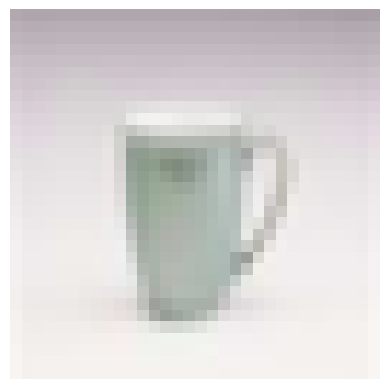

In [17]:
img = images[7].reshape(3, 32, 32)
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
images.shape, len(labels)

((50000, 3072), 50000)

In [19]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.transforms as transforms

In [20]:
class CustomDataset(Dataset):
    def __init__(self, images:np.ndarray, labels:list[int], transform=None):
        assert images.shape[0] == len(labels)
        
        self.images = images.reshape(-1, 3, 32, 32)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i]
        img = np.transpose(img, (1, 2, 0))
        
        if self.transform:
            img = self.transform(img)
            
        return img, self.labels[i]

In [21]:
test_images, test_labels = test_dict[b'data'], test_dict[b'fine_labels']
test_images.shape, len(test_labels)

((10000, 3072), 10000)

In [22]:
IMG_DIM=227

train_trasform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])
test_trasform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])

In [23]:
train_ds = CustomDataset(images, labels, train_trasform)
test_ds = CustomDataset(test_images, test_labels, test_trasform)

In [24]:
batch_size=64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [25]:
print(images.shape)
print(images.dtype)

img = images[0]
print(img.shape)

img = img.reshape(3, 32, 32)
print(img.shape)

img = np.transpose(img, (1, 2, 0))
print(img.shape)

(50000, 3072)
uint8
(3072,)
(3, 32, 32)
(32, 32, 3)


In [26]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 227, 227])
torch.Size([64])


In [27]:
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            # 224,224,3
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            # (224-11)/4 + 1 = 54,54,96
            nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(3,2),
            # 27,27,128

            # Layer 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            # 27-5+4+1 = 27,27,256
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(3,2),
            # 13,13,256

            # Layer 3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            # 13-3+2+1 = 13
            nn.ReLU(inplace=True),
            
            # Layer 4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            # 13-3+2+1 = 13
            nn.ReLU(inplace=True),

            # Layer 4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            # 13-3+2+1 = 13
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3,2),
            # 6,6,256
            nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2.0),            
        )
        self.linear = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
        
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
        
            nn.Linear(4096, 100),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.linear(x)
        return x

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [29]:
model = AlexNet()
model = model.to(device)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
  )
  (linear)

In [30]:
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)

In [31]:
epochs = 10

In [32]:
next(iter(train_loader))[0].shape

torch.Size([64, 3, 227, 227])

In [33]:
for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Evaluation after each epoch
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [2/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [3/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [4/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [5/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [6/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [7/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [8/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [9/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%
Epoch [10/10] | Train Loss: -0.0100 | Test Loss: -0.0100 | Accuracy: 1.00%


In [34]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_test_loss = test_loss / len(test_loader)
accuracy = 100 * correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Test Loss: -0.0100
Accuracy: 1.00%
